# Análise Base Diabetes (Pima Indians)

Este notebook importa a base original direto do Kaggle para prepararmos para os treinamentos.

In [56]:
%pip install kagglehub pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 330.3 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 650.2 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 546.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------------------------- 119.8/119.8 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB 9.9 MB/s eta 0:00:01
   --- ------------------------------------ 0.6/8.1 MB 8.0 MB/s eta 0:00:01
   ---- ----------------------------------- 1.0/8.1 MB 9.0 MB/s eta 0:00:01
   ------ --------------------------------- 1.4/8.1 MB 10.0 MB/s eta 0:00:01
   --------- ------------------------------ 1.9/8.1 MB 11.3 MB/s eta 0:00:01
   ------------ --------------------------- 2.4/8.1 MB 11.2 MB/s eta 0:00:01
   ----


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#Preparando arquivo direto do kaggle
path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Path to dataset files:", path)

files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
dataset_path = os.path.join(path, csv_file)
print(f"Encontrado CSV em: {dataset_path}")

#Configuracoes do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#Configuracoes do matplotlib
plt.rcParams['figure.figsize'] = (15, 10)

Path to dataset files: C:\Users\soulo\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1
Encontrado CSV em: C:\Users\soulo\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1\diabetes.csv


In [58]:
#Analise inicial do formato do dataset
df = pd.read_csv(dataset_path)
print("Formato do dataset:", df.shape)
df.head()



Formato do dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [60]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Ha desbalanceamento entre as targets, eventualmente precisaremos de tecnicas de pre-processamento antes de escolher o modelo

In [61]:
df.groupby("Outcome").describe().T

Outcome                                  0           1
Pregnancies              count  500.000000  268.000000
                         mean     3.298000    4.865672
                         std      3.017185    3.741239
                         min      0.000000    0.000000
                         25%      1.000000    1.750000
                         50%      2.000000    4.000000
                         75%      5.000000    8.000000
                         max     13.000000   17.000000
Glucose                  count  500.000000  268.000000
                         mean   109.980000  141.257463
                         std     26.141200   31.939622
                         min      0.000000    0.000000
                         25%     93.000000  119.000000
                         50%    107.000000  140.000000
                         75%    125.000000  167.000000
                         max    197.000000  199.000000
BloodPressure            count  500.000000  268.000000
                         mean    68.184000   70.824627
                         std     18.063075   21.491812
                         min      0.000000    0.000000
                         25%     62.000000   66.000000
                         50%     70.000000   74.000000
                         75%     78.000000   82.000000
                         max    122.000000  114.000000
SkinThickness            count  500.000000  268.000000
                         mean    19.664000   22.164179
                         std     14.889947   17.679711
                         min      0.000000    0.000000
                         25%      0.000000    0.000000
                         50%     21.000000   27.000000
                         75%     31.000000   36.000000
                         max     60.000000   99.000000
Insulin                  count  500.000000  268.000000
                         mean    68.792000  100.335821
                         std     98.865289  138.689125
                         min      0.000000    0.000000
                         25%      0.000000    0.000000
                         50%     39.000000    0.000000
                         75%    105.000000  167.250000
                         max    744.000000  846.000000
BMI                      count  500.000000  268.000000
                         mean    30.304200   35.142537
                         std      7.689855    7.262967
                         min      0.000000    0.000000
                         25%     25.400000   30.800000
                         50%     30.050000   34.250000
                         75%     35.300000   38.775000
                         max     57.300000   67.100000
DiabetesPedigreeFunction count  500.000000  268.000000
                         mean     0.429734    0.550500
                         std      0.299085    0.372354
                         min      0.078000    0.088000
                         25%      0.229750    0.262500
                         50%      0.336000    0.449000
                         75%      0.561750    0.728000
                         max      2.329000    2.420000
Age                      count  500.000000  268.000000
                         mean    31.190000   37.067164
                         std     11.667655   10.968254
                         min     21.000000   21.000000
                         25%     23.000000   28.000000
                         50%     27.000000   36.000000
                         75%     37.000000   44.000000
                         max     81.000000   70.000000

In [62]:
#Aprofundamento da analise dos dados
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


### Variáveis Preditivas Principais (Correlação com o Target `Outcome`)
A análise das métricas evidencia diferentes níveis de potencial preditivo entre as variáveis disponíveis:
* **Preditores Fortes:** As variáveis `Glucose` (**0.46**) e `BMI` (**0.29**) apresentam os maiores índices de correlação positiva com a prevalência da doença, configurando-se como os principais descritores para a construção do modelo.
* **Preditores Secundários:** Em um patamar secundário de relevância preditiva figuram as métricas contextuais do paciente, representadas pelas variáveis `Age` (**0.23**), `Pregnancies` (**0.22**) e `DiabetesPedigreeFunction` (**0.17**).
* **Preditores de Baixo Impacto:** Variáveis de natureza fisiológica contínua, especificamente `SkinThickness` (**0.07**) e `BloodPressure` (**0.06**), demonstram correlação quase nula com o desfecho. Em otimizações avançadas focadas em redução de dimensionalidade computacional, a exclusão temporária das mesmas pode ser considerada.

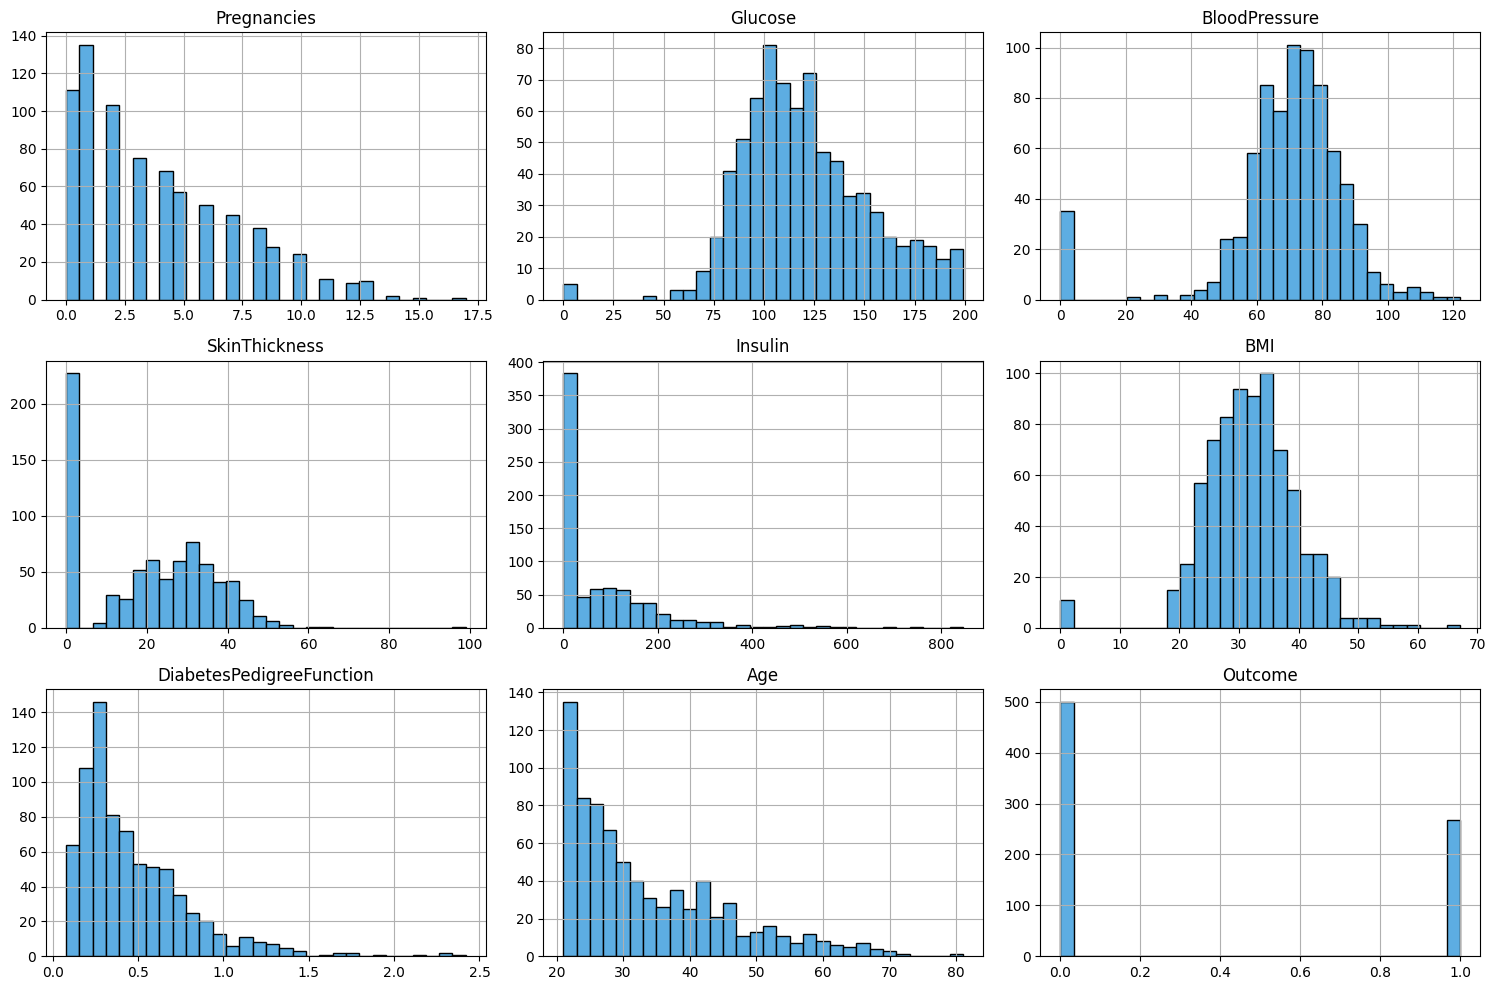

In [66]:
df.hist(bins=30, color='#5dade2', edgecolor='black')
# Exibe na tela
plt.tight_layout()
plt.show()

In [63]:
#Preparacao das bases de treino e testes
X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

